## Contornos

In [ ]:
#Si queremos que las imágenes sean mostradas en una ventana emergente quitar el inline

# OpenCV-Python utiliza NumPy para el manejo de imágenes
import numpy as np
# cv2 es el módulo python para acceder a OpenCV 
import cv2 as cv
# Usamos las poderosas herramientas de graficación de matplotlib para mostrar imágenes, perfiles, histogramas, etc
import supervision as sv

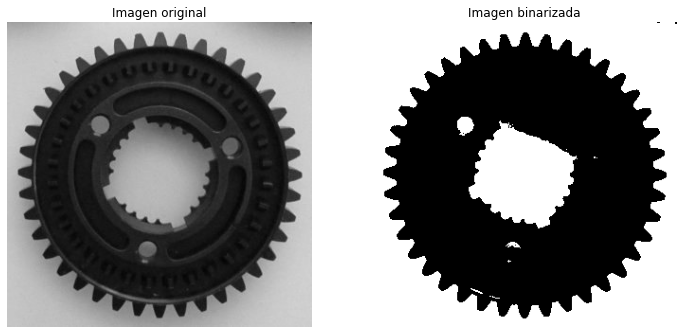

In [36]:
# Leemos la imagen y la binarizamos
#==================================
img = cv.imread('engranaje.jpg')

imgray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Binarizamos con Otzu
ret, img_bin = cv.threshold(imgray,30,255,cv.THRESH_BINARY+cv.THRESH_OTSU)

sv.plot_images_grid(images=[img, img_bin], titles=['Imagen original', 'Imagen binarizada'], grid_size=(1, 2))
cv.imshow('Original',img_bin)
#cv.imshow('Original_gris',img)

### Cálculo

El cálculo de contornos tiene un parámetro obligatorio de modo:

- cv.RETR_LIST: Contornos sin relación de jerarquías
- cv.RETR_CCOMP: Contornos con dos niveles de jerarquía --> Contorno externos y contornos internos
- cv.RETR_TREE: Mapeo completo de jerarquías, inclusive para contornos anidados.

Y un parámetro optativo de método:

- cv.CHAIN_APPROX_NONE: Devuelve todos los puntos del contorno
- cv.CHAIN_APPROX_SIMPLE: Comprime los segmentos horizontales y verticales (devuelve solo los extremos)
- cv.CHAIN_APPROX_TC89_L1: Aproximación según el algoritmo de Ten-Chin
- cv.CHAIN_APPROX_TC89_KCOS: Aproximación según el algoritmo de Ten-Chin


In [40]:
# Calculamos los contornos
contours, hierarchy = cv.findContours(img_bin, cv.RETR_TREE, cv.CHAIN_APPROX_NONE)
# Para el caso del engranaje no hay nada que pueda simplificar
#im2, contours, hierarchy = cv.findContours(img_bin, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

# Me fijo cuántos contornos se encontraron
print(contours)

(array([[[0, 0]],

       [[0, 1]],

       [[0, 2]],

       ...,

       [[3, 0]],

       [[2, 0]],

       [[1, 0]]], dtype=int32), array([[[159,  11]],

       [[160,  10]],

       [[161,  10]],

       ...,

       [[157,  14]],

       [[158,  13]],

       [[158,  12]]], dtype=int32), array([[[127, 289]],

       [[127, 290]],

       [[128, 290]],

       [[129, 290]],

       [[130, 291]],

       [[131, 291]],

       [[132, 291]],

       [[133, 291]],

       [[134, 291]],

       [[133, 291]],

       [[132, 291]],

       [[131, 291]],

       [[130, 291]],

       [[129, 290]],

       [[128, 290]]], dtype=int32), array([[[124, 289]],

       [[125, 289]]], dtype=int32), array([[[104, 281]],

       [[105, 282]],

       [[106, 282]],

       [[107, 283]],

       [[108, 283]],

       [[109, 284]],

       [[110, 284]],

       [[111, 284]],

       [[112, 285]],

       [[113, 285]],

       [[114, 286]],

       [[115, 286]],

       [[116, 286]],

       [[115, 285

### Dibujo

Podemos dibujar todos los contornos encontrados o contornos individuales

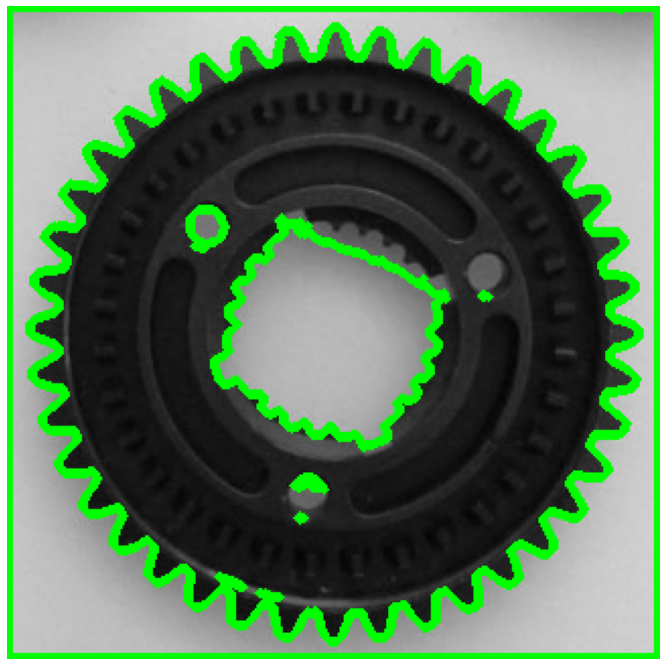

In [41]:
# Dibujamos todos los contornos (indicado con el -1)
#---------------------------------------------------
img_out = img.copy()
cv.drawContours(img_out, contours, -1, (0, 255, 0), 3)
sv.plot_image(img_out)


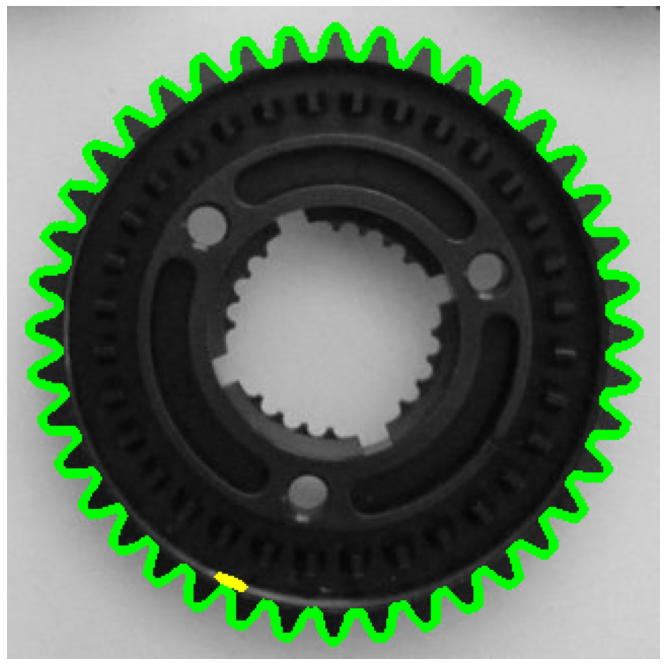

In [43]:


# Dibujamos un contorno en particular
#------------------------------------
img_out = img.copy()
cv.drawContours(img_out, contours, 1, (0,255,0), 3)
# Otra manera de elegir un contorno en particular
cnt = contours[4]
cv.drawContours(img_out, [cnt], 0, (0,255,255), 3)

sv.plot_image(img_out)

### Jerarquías

Es posible pedir mayor o menor información de jerarquías según sea necesario. Para eso disponemos del parámetro de modo

- cv.RETR_LIST: Contornos sin relación de jerarquías
- cv.RETR_CCOMP: Contornos con dos niveles de jerarquía --> Contorno externos y contornos internos
- cv.RETR_TREE: Mapeo completo de jerarquías, inclusive para contornos anidados.


- __Orden:__ [Next, Previous, First_Child, Parent]

In [44]:
# Contornos sin relación de jerarquía
contours, hierarchy = cv.findContours(img_bin, cv.RETR_LIST, cv.CHAIN_APPROX_NONE)
print('Lista: {} \n'.format(hierarchy))

# Contornos en dos niveles de jerarquía
contours, hierarchy = cv.findContours(img_bin, cv.RETR_CCOMP, cv.CHAIN_APPROX_NONE)
print('Dos niveles: {} \n'.format(hierarchy))

# Contornos con mapeo completo de jerarquía
contours, hierarchy = cv.findContours(img_bin, cv.RETR_TREE, cv.CHAIN_APPROX_NONE)
print('Full: {} \n'.format(hierarchy))

Lista: [[[ 1 -1 -1 -1]
  [ 2  0 -1 -1]
  [ 3  1 -1 -1]
  [ 4  2 -1 -1]
  [ 5  3 -1 -1]
  [ 6  4 -1 -1]
  [ 7  5 -1 -1]
  [ 8  6 -1 -1]
  [ 9  7 -1 -1]
  [10  8 -1 -1]
  [11  9 -1 -1]
  [12 10 -1 -1]
  [13 11 -1 -1]
  [14 12 -1 -1]
  [15 13 -1 -1]
  [16 14 -1 -1]
  [-1 15 -1 -1]]] 

Dos niveles: [[[ 1 -1 -1 -1]
  [ 2  0 -1 -1]
  [ 3  1 -1 -1]
  [ 4  2 -1 -1]
  [ 7  3  5 -1]
  [ 6 -1 -1  4]
  [-1  5 -1  4]
  [ 8  4 -1 -1]
  [ 9  7 -1 -1]
  [10  8 -1 -1]
  [11  9 -1 -1]
  [13 10 12 -1]
  [-1 -1 -1 11]
  [15 11 14 -1]
  [-1 -1 -1 13]
  [-1 13 16 -1]
  [-1 -1 -1 15]]] 

Full: [[[-1 -1  1 -1]
  [-1 -1  2  0]
  [ 3 -1 -1  1]
  [ 4  2 -1  1]
  [ 5  3 -1  1]
  [ 6  4 -1  1]
  [ 9  5  7  1]
  [ 8 -1 -1  6]
  [-1  7 -1  6]
  [10  6 -1  1]
  [11  9 -1  1]
  [12 10 -1  1]
  [13 11 -1  1]
  [15 12 14  1]
  [-1 -1 -1 13]
  [-1 13 16  1]
  [-1 -1 -1 15]]] 



### Operaciones

Veamos algunas operaciones que podemos hacer con los contornos

#### Perímetro y Área

In [45]:
# Veamos qué longitud tienen por ejemplo los contornos hallados

for cnt in contours:
    print('Longitud: {} - Área: {}'.format(cv.arcLength(cnt, False), cv.contourArea(cnt)))
    

Longitud: 1283.2426406145096 - Área: 103034.5
Longitud: 1679.4570552110672 - Área: 65247.0
Longitud: 14.828427076339722 - Área: 0.5
Longitud: 1.0 - Área: 0.0
Longitud: 27.14213538169861 - Área: 10.0
Longitud: 6.2426406145095825 - Área: 2.0
Longitud: 39.041630148887634 - Área: 40.5
Longitud: 4.2426406145095825 - Área: 2.0
Longitud: 4.2426406145095825 - Área: 2.0
Longitud: 0.0 - Área: 0.0
Longitud: 3.0 - Área: 1.0
Longitud: 0.0 - Área: 0.0
Longitud: 0.0 - Área: 0.0
Longitud: 451.03152549266815 - Área: 7938.5
Longitud: 8.656854152679443 - Área: 6.0
Longitud: 62.69848430156708 - Área: 234.5
Longitud: 4.2426406145095825 - Área: 2.0


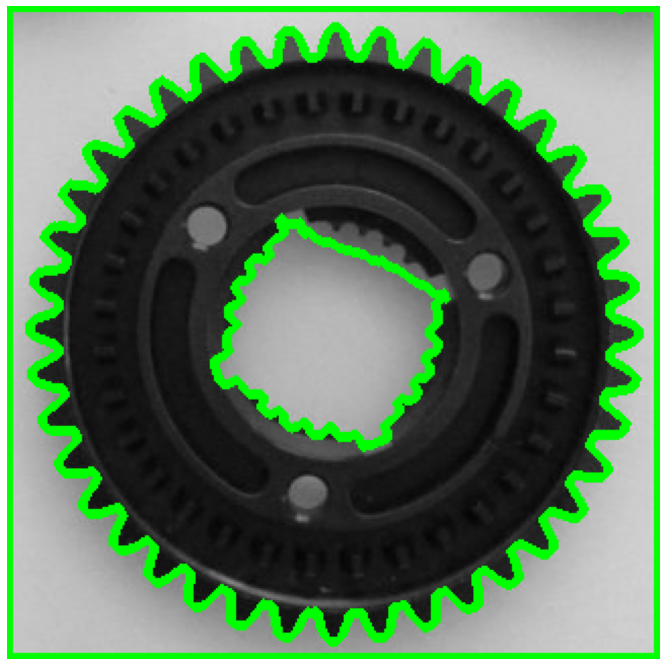

In [46]:
#Veámoslos...
img_out = img.copy()

# De arriba ya vemos que (sin mirar las jerarquías) tenemos tres perímetros áreas mayores: 0, 1, y 13

CNTR_IDX = [0, 1, 13]
for idx in CNTR_IDX:
    cnt = contours[idx]
    cv.drawContours(img_out, [cnt], 0, (0,255,0), 3)

cv.drawContours(img_out, [cnt], 0, (0,255,0), 3)
sv.plot_image(img_out)

#### Centroide

Para encontrar el centroide debemos calcular primero los momentos

Centroide: [160,161]


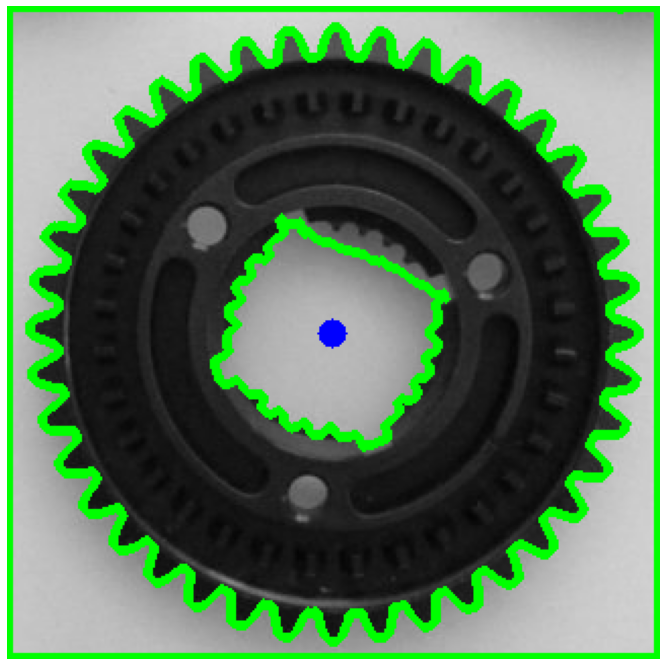

Tamaño imagen: (322, 322, 3)
Centro imagen: [161,161]


In [48]:
# Calculamos primero los momentos
cnt = contours[1]
M = cv.moments(cnt)
#print( M )

# Ahora calculamos el centroide
cx = int(M['m10']/M['m00'])
cy = int(M['m01']/M['m00'])

print('Centroide: [{},{}]'.format(cx,cy))

cv.circle(img_out, (cx, cy), 7, (255, 0, 0), -1)
sv.plot_image(img_out)

# Debería parecerse bastante al centro de la imagen...
size = img.shape
print('Tamaño imagen: {}'.format(size))
print('Centro imagen: [{},{}]'.format(int(size[0]/2), int(size[1]/2)))

#### Convex Hull

Es una aproximación de casquete convexo sobre la geometría indicada

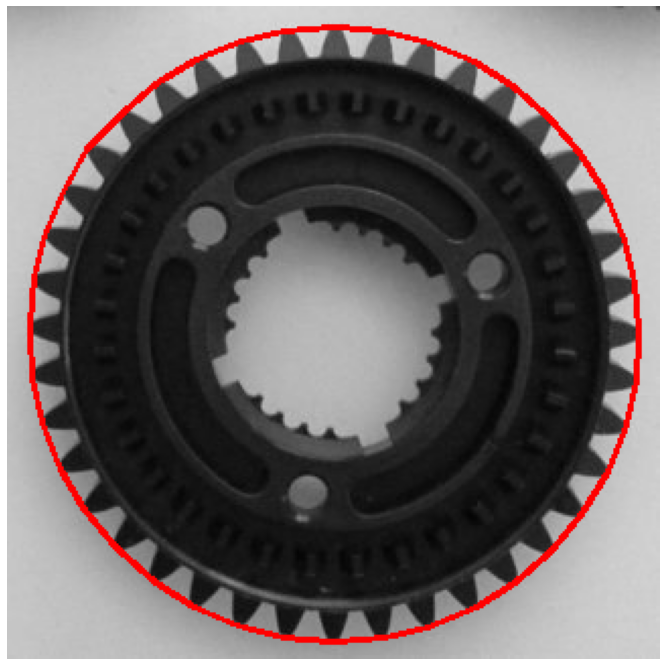

In [49]:
# Lo calculamos...
cnt = contours[1]
hull = cv.convexHull(cnt)

# Lo dibujamos
img_out = img.copy()
cv.drawContours(img_out, [hull], -1, (0, 0, 255), 2)

sv.plot_image(img_out)


#### Bounding Box

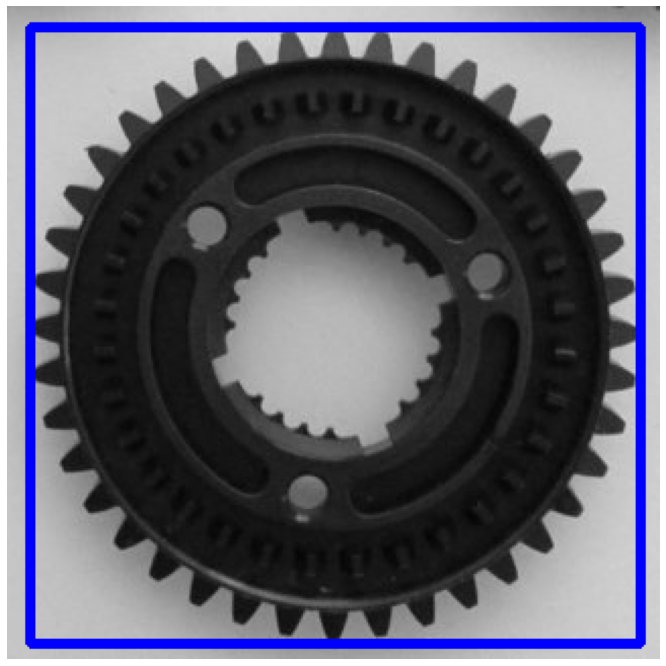

In [50]:
# Calculamos...
cnt = contours[1]
x,y,w,h = cv.boundingRect(cnt)

# Lo dibujamos...
img_out = img.copy()
cv.rectangle(img_out,(x,y),(x+w,y+h),(255,0,0),3)
sv.plot_image(img_out)

#### Bounding Box Rotado

A veces el rectángulo que mejor ajusta está rotado.

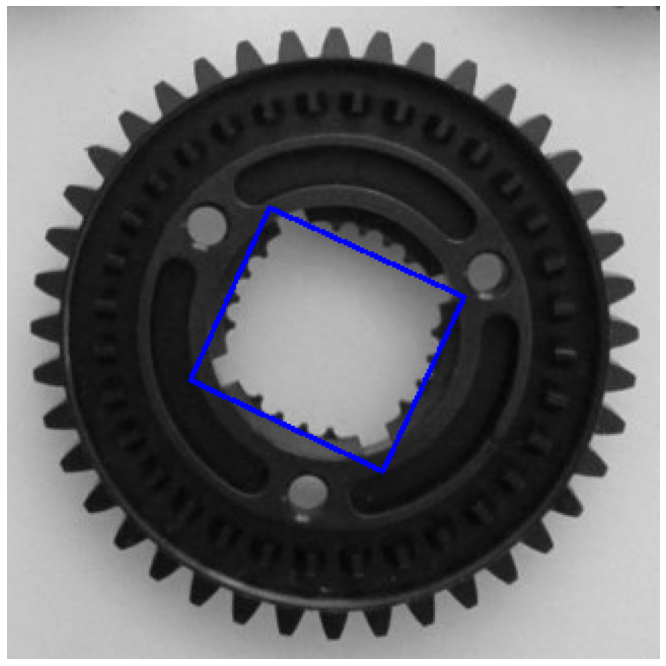

In [51]:
# Lo calculamos...
cnt = contours[13]
rect = cv.minAreaRect(cnt)
box = cv.boxPoints(rect)
box = np.int0(box)

# Lo dibujamos...
img_out = img.copy()
cv.drawContours(img_out,[box],0,(255,0,0),2)
sv.plot_image(img_out)

#### Ajuste de un círculo

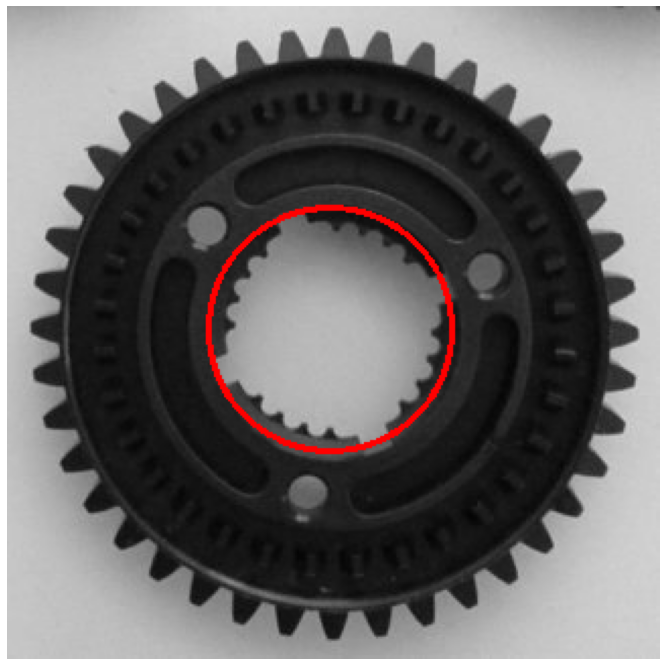

In [52]:
# Lo calculamos...
cnt = contours[13]
(x,y),radius = cv.minEnclosingCircle(cnt)
center = (int(x),int(y))
radius = int(radius)

# Lo dibujamos...
img_out = img.copy()
cv.circle(img_out,center,radius,(0,0,255),2)
sv.plot_image(img_out)

#### Ajuste de una elipse

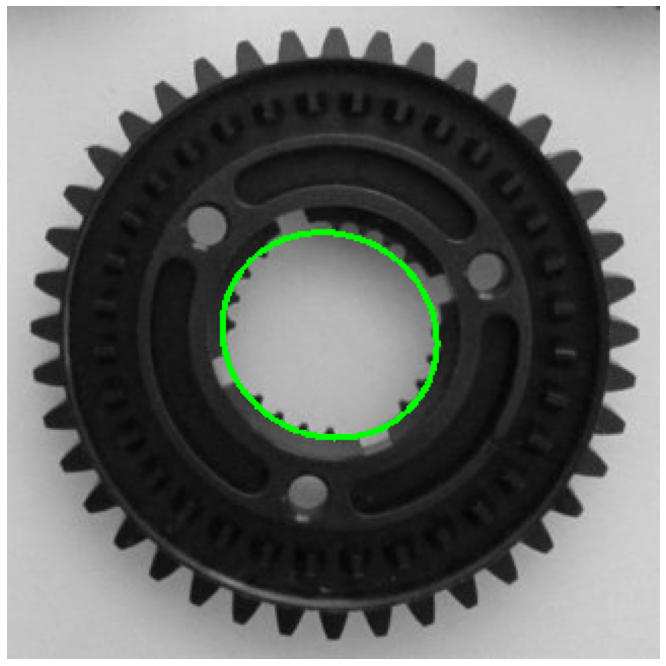

In [53]:
# Lo calculamos...
cnt = contours[13]
ellipse = cv.fitEllipse(cnt)

# Lo dibujamos...
img_out = img.copy()
cv.ellipse(img_out,ellipse,(0,255,0),2)
sv.plot_image(img_out)

#### Ajuste de recta

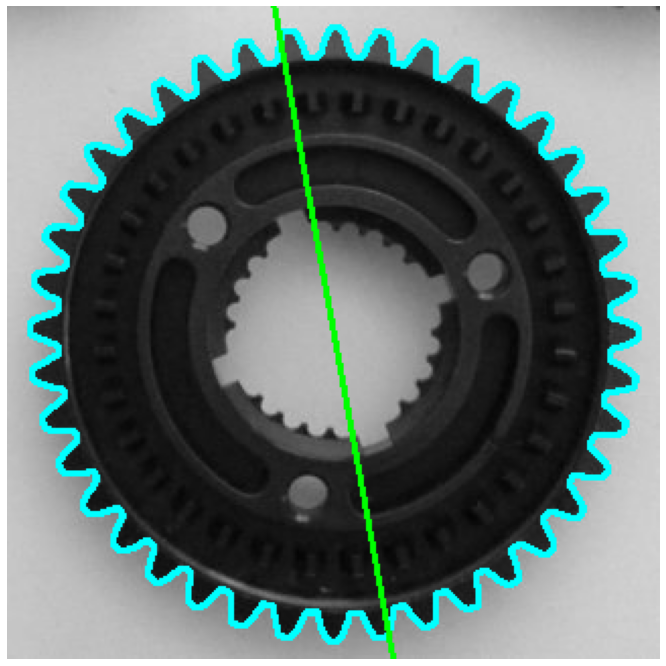

In [54]:
rows,cols = img.shape[:2]
# Lo calculamos...
cnt = contours[1]
[vx,vy,x,y] = cv.fitLine(cnt, cv.DIST_L2,0,0.01,0.01)
lefty = int((-x*vy/vx) + y)
righty = int(((cols-x)*vy/vx)+y)

# Lo dibujamos...
img_out = img.copy()
cv.drawContours(img_out,[cnt],0,(255,255,0),2)
cv.line(img_out,(cols-1,righty),(0,lefty),(0,255,0),2)
sv.plot_image(img_out)

### Propiedades de los contornos


Además del centroide, área y perímetro tenemos otras magnitudes a evaluar con los contornos

- Relación de aspecto
- Extensión
- Solidez
- Diámetro equivalente
- Orientación

In [55]:
# Elegimos el contorno a evaluar
cnt = contours[1]

# Relación de aspecto
x,y,w,h = cv.boundingRect(cnt)
aspect_ratio = float(w)/h
print('Relación de aspecto: {}'.format(aspect_ratio))

# Extensión (Relación entre el área del objeto y del bounding box)
area = cv.contourArea(cnt)
x,y,w,h = cv.boundingRect(cnt)
rect_area = w*h
extent = float(area)/rect_area
print('Extensión:           {}'.format(extent))

# Solidez (Relación entre el área del objeto y del casquete convexo)
area = cv.contourArea(cnt)
hull = cv.convexHull(cnt)
hull_area = cv.contourArea(hull)
solidity = float(area)/hull_area
print('Solidez:             {}'.format(solidity))

# Diámetro equivalente (Diámetro de un círculo que tendría la misma área que el objeto)
area = cv.contourArea(cnt)
equi_diameter = np.sqrt(4*area/np.pi)
print('Diámetro equivalente:{}'.format(equi_diameter))

# Orientación (Con respecto a la horizontal)
(x,y),(MA,ma),angle = cv.fitEllipse(cnt)
print('Orientación:         {}'.format(angle))

Relación de aspecto: 0.9901315789473685
Extensión:           0.7130507955936353
Solidez:             0.914354982237575
Diámetro equivalente:288.22744590919024
Orientación:         164.1798095703125


#### Máscaras

Definido un contorno muchas veces es útil generar una máscara alrededor del mismo para análisis localizados

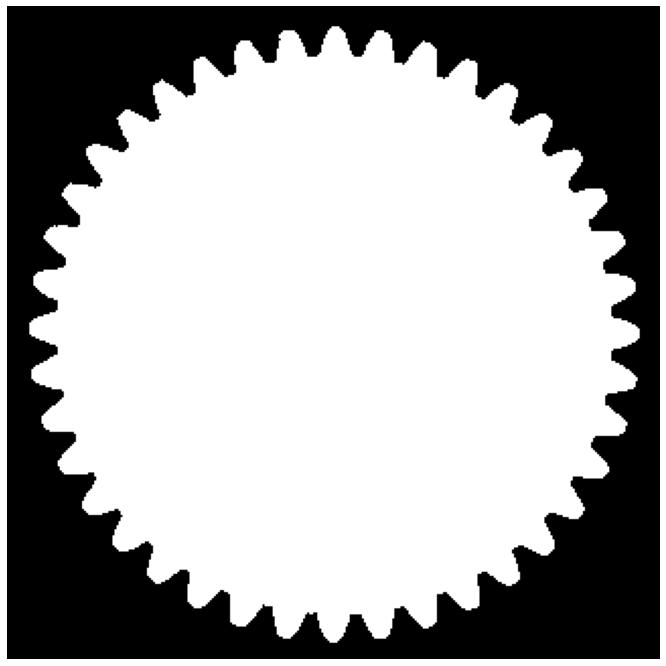

In [57]:
# Elegimos el contorno a evaluar
cnt = contours[1]

# Armamos la base de la máscara en función de la imagen original
mask = np.zeros(imgray.shape, np.uint8)

# Luego marcamos únicamente el contorno (el último parámetro en -1 indica "llenar" el contorno)
cv.drawContours(mask,[cnt],0,255,-1)
pixelpoints = np.transpose(np.nonzero(mask))

sv.plot_image(mask)

In [58]:
# A partir de esta máscara podemos calcular valores sobre la imagen original

# Intensidades mínimas/máximas
min_val, max_val, min_loc, max_loc = cv.minMaxLoc(imgray,mask = mask)
print('[min val, max val, min loc, max loc]: [{},{},{},{}]'.format(min_val, max_val, min_loc, max_loc))


# Valor de intensidad media
mean_val = cv.mean(imgray, mask = mask)
print('Promedio: {}'.format(mean_val[0]))

# Etc.

[min val, max val, min loc, max loc]: [4.0,211.0,(227, 100),(112, 22)]
Promedio: 52.17130296369287


#### Defectos de convexidad

Analizar la diferencia entre un objeto y el casquete convexo que lo contiene

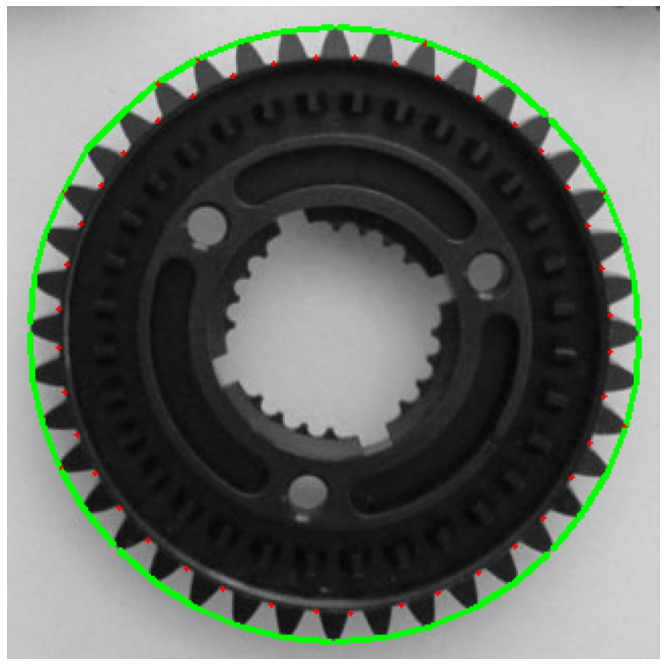

In [59]:
# Elegimos el contorno a evaluar
cnt = contours[1]

# Calculamos el casquete y diferencias
hull = cv.convexHull(cnt,returnPoints = False)
defects = cv.convexityDefects(cnt, hull)

# Dibujamos...
img_out = img.copy()

for i in range(defects.shape[0]):
    s,e,f,d = defects[i,0]
    start = tuple(cnt[s][0])
    end = tuple(cnt[e][0])
    far = tuple(cnt[f][0])
    cv.line(img_out,start,end,[0,255,0],2)
    cv.circle(img_out,far,1,[0,0,255],-1)

sv.plot_image(img_out)
#plt.imshow(img_out)

### Coincidencia de figuras

#### Verificación por aproximación de parámetros

In [ ]:
# Cargamos la imagen
img = cv.imread('figuras.png')

# Convertimos a grises
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Convertimos a imagen binaria
_, threshold = cv.threshold(img_gray, 245, 255, cv.THRESH_BINARY_INV)

# Encontramos contornos
contours, _ = cv.findContours(threshold, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

i=0;
# Para cada contornos aproximamos una curva y detectamos las formas
for cnt in contours:
    epsilon = 0.01*cv.arcLength(cnt, True)
    approx = cv.approxPolyDP(cnt, epsilon, True)
    cv.drawContours(img, [approx], 0, (0), 3)
    # Posición para escribir textos
    x,y = approx[0][0]

    if len(approx) == 3:
        cv.putText(img, "Triangulo", (x, y), cv.FONT_HERSHEY_COMPLEX, 1, 0,2)
        print('Triángulo: {}'.format(i))
        i+=1;
    elif len(approx) == 4:
        #cv.putText(img, "Rectangulo", (x, y), cv.FONT_HERSHEY_COMPLEX, 1, 0,2)
        #print('Rectángulo: {}'.format(i))
        
        
        # Versión para discriminar rombos
        area = cv.contourArea(cnt)
        _,_,w,h = cv.boundingRect(cnt)
        rect_area = w*h
        extension = float(area)/rect_area
        if (extension > 0.4 and extension < 0.6):
            cv.putText(img, "Rombo", (x, y), cv.FONT_HERSHEY_COMPLEX, 1, 0,2)
            print('Rombo: {}'.format(i))
        else:
            cv.putText(img, "Rectangulo", (x, y), cv.FONT_HERSHEY_COMPLEX, 1, 0,2)
            print('Rectangulo: {}'.format(i))
        i+=1;
    elif len(approx) == 5:
        cv.putText(img, "Pentagono", (x, y), cv.FONT_HERSHEY_COMPLEX, 1, 0,2)
        print('Pentángono: {}'.format(i))
        i+=1;
    elif len(approx) == 6:
        cv.putText(img, "Hexagono", (x, y), cv.FONT_HERSHEY_COMPLEX, 1, 0,2)
        print('Hexágono: {}'.format(i))
        i+=1;
    elif 6 < len(approx) < 15:
        cv.putText(img, "Elipse", (x, y), cv.FONT_HERSHEY_COMPLEX, 1, 0,2)
        print('Elipse: {}'.format(i))
        i+=1;
    else:
        cv.putText(img, "Circulo", (x, y), cv.FONT_HERSHEY_COMPLEX, 1, 0,2)
        print('Círculo: {}'.format(i))
        i+=1;
cv.imshow("final", img)

#### Verificación contra contorno conocido

In [ ]:
# Contorno de referencia
refcnt = contours[1]

for cnt in contours:
    ret = cv.matchShapes(refcnt, cnt,1,0.0)
    print(f'Coincidencia: {ret}')

Coincidencia: 0.028161405102645753
Coincidencia: 0.0
Coincidencia: 0.2739968358951608
Coincidencia: 1.7976931348623157e+308
Coincidencia: 24.318417550026012
Coincidencia: 0.028198694485702447
Coincidencia: 0.604636442401697
Coincidencia: 0.028198694485702447
Coincidencia: 0.028198694485702447
Coincidencia: 1.7976931348623157e+308
Coincidencia: 0.02819869447004697
Coincidencia: 1.7976931348623157e+308
Coincidencia: 1.7976931348623157e+308
Coincidencia: 0.015526136135232571
Coincidencia: 0.1084872313904226
Coincidencia: 0.015901236636536753
Coincidencia: 0.028198694493530185


: 